# Study 852 — Movie-Sequel Fatigue 🎬

*For the curious.* Everyone *knows* franchises get tired: *Ant-Man: Quantumania*, *The Marvels*, *Indiana Jones 5*, *Fast X* — later sequels open softer, reviews sour, the magic fades. If that's real, the reflex trade is obvious: the **studio** should react worse to sequel N than to sequel N-1. We put **46 franchise entries** (Marvel, Star Wars, Fast & Furious, Jurassic World, Pirates, Transformers) on the stand and asked the tape: **does the studio's stock actually flinch harder as the franchise ages?** The answer is a shrug with one asterisk.

## The claim, and why it's a clean test

A wide release opens on a known Friday; the *weekend* box-office is public by Sunday/Monday. So the first session at which 'how it opened' is common knowledge is the **Monday after opening** — we anchor the studio-reaction window there (base = the opening-Friday close), measure the studio's **abnormal** return (studio − SPY, total-return), and index each film by its **sequel number**. Zero look-ahead.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sequel_fatigue import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching DIS + CMCSA + PARA + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
cars = st.build_event_cars(prices)
inc = cars[cars["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} franchise entries resolved")


panel loaded; 43 of 46 franchise entries resolved


## The franchise calendar we test (hardcoded from Box Office Mojo / studio releases)

In [2]:
dt.events_frame()[['franchise','title','seq','opening','ticker']]

,franchise,title,seq,opening,ticker
0,Ant-Man,Ant-Man,1,2015-07-17,DIS
1,Ant-Man,Ant-Man and the Wasp,2,2018-07-06,DIS
2,Ant-Man,Ant-Man and the Wasp: Quantumania,3,2023-02-17,DIS
3,Avengers,The Avengers,1,2012-05-04,DIS
4,Avengers,Avengers: Age of Ultron,2,2015-05-01,DIS
5,Avengers,Avengers: Infinity War,3,2018-04-27,DIS
6,Avengers,Avengers: Endgame,4,2019-04-26,DIS
7,Black Panther,Black Panther,1,2018-02-16,DIS
8,Black Panther,Black Panther: Wakanda Forever,2,2022-11-11,DIS
9,Captain America,Captain America: The Winter Soldier,2,2014-04-04,DIS


## The picture: mean studio reaction by sequel number

If 'fatigue' is real, this should slope **down** — later sequels drawing a worse opening reaction. It does tilt down, but shallowly, and the scatter is a cloud.

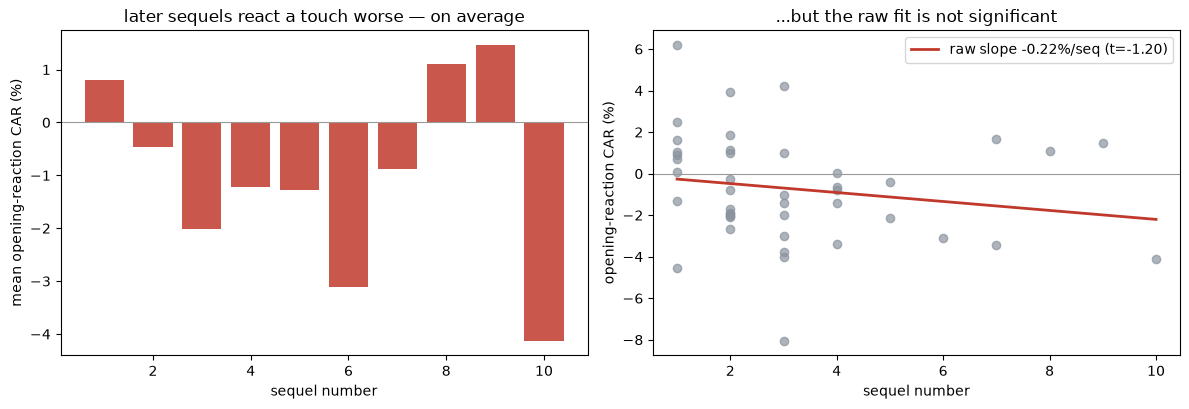

In [3]:
g = inc.groupby('seq')['car'].mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(g.index, g.values, color='#c0392b', alpha=0.85)
ax[0].axhline(0, color='0.6', lw=0.8)
ax[0].set_xlabel('sequel number'); ax[0].set_ylabel('mean opening-reaction CAR (%)')
ax[0].set_title('later sequels react a touch worse — on average')
sl = st.fatigue_slope(inc, demean=False)
ax[1].scatter(inc['seq'], inc['car']*100, color='#8b949e', alpha=0.7)
xs = np.array([inc['seq'].min(), inc['seq'].max()])
ax[1].plot(xs, (sl['intercept'] + sl['slope']*xs)*100, color='#c0392b', lw=2,
           label=f"raw slope {sl['slope']*100:+.2f}%/seq (t={sl['t']:+.2f})")
ax[1].axhline(0, color='0.6', lw=0.8); ax[1].legend()
ax[1].set_xlabel('sequel number'); ax[1].set_ylabel('opening-reaction CAR (%)')
ax[1].set_title('...but the raw fit is not significant')
plt.tight_layout(); plt.show()

## The numbers

| what | value |
|---|--:|
| mean opening reaction (all 43) | **-0.73%** (NW *t* = -2.06) |
| raw fatigue slope (CAR vs sequel #) | **-0.22%/seq** (*t* = -1.20) |
| within-franchise slope (fixed effect) | **-0.90%/seq** (*t* = -3.05) |

Studios do dip a mild **0.73%** in the week a sequel opens, and the fatigue slope points the *right way* (negative). But the *natural* reading — 'CAR declines with sequel number' — is **insignificant** (*t* = -1.20). It only becomes significant once you add a franchise fixed effect (*t* = -3.05)... and that's where the story gets slippery.

In [4]:
for label, dem in [('raw', False), ('franchise fixed effect', True)]:
    s = st.fatigue_slope(inc, demean=dem)
    print(f'{label:<24s} slope={s["slope"]*100:+.3f}%/seq  t={s["t"]:+.3f}  r={s["r"]:+.3f}')

raw                      slope=-0.216%/seq  t=-1.196  r=-0.184
franchise fixed effect   slope=-0.902%/seq  t=-3.054  r=-0.430


## The asterisk: it's a recent-era artifact

Split the within-franchise slope by era and the 'signal' evaporates before 2018:

| era | n | slope | *t* |
|---|--:|--:|--:|
| early (< 2018) | 25 | -0.41%/seq | -0.95 |
| late (≥ 2018) | 18 | -3.50%/seq | -8.85 |

All of the 'fatigue' lives in the post-2018 window (a handful of 2-entry franchises), and even the mean reaction sits **inside** a random-date placebo cloud (p = 0.11). So: the right sign, one significant-but-fragile specification, nothing you'd bet on.

In [5]:
era = st.era_slopes(inc, demean=True)
for k in ('early','late'):
    e = era[k]; print(f'{k:<6s} n={e["n"]:2d}  slope={e["slope"]*100:+.3f}%/seq  t={e["t"]:+.3f}')

early  n=25  slope=-0.405%/seq  t=-0.952
late   n=18  slope=-3.504%/seq  t=-8.853


## So what?

'Franchise fatigue' is *directionally* real in studio reactions — later sequels do draw a slightly worse opening move — but it's insignificant in its natural form, reaches significance only in a fixed-effect specification that is entirely a post-2018 artifact, and the average reaction is indistinguishable from random dates. **Verdict: Weak signal, Fragile tradability.** The quants' notebook has the two placebos, the persistence test, the costed short, and the synthetic control.